In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import os

def extract_gc(vGRFdata, threshold, close_threshold=100):
    """
    Extract heel strike indices and form gait cycle segments from GRF data.
    """
    vgrf = vGRFdata.copy()
    # Create binary GRF signal based on threshold
    bi_vgrf = np.where(vgrf < threshold, 0, 1)
    diff_vgrf = np.diff(bi_vgrf)
    # Find indices where the signal goes from 0 to 1
    heelstrike_index = np.where(diff_vgrf == 1)[0] + 1

    # Remove heel strike indices that are too close to each other
    if len(heelstrike_index) > 1:
        diff = np.diff(heelstrike_index)
        # Find indices where the difference is less than 100
        close_idx = np.where(diff < 100)[0]
        # Remove the heel strike indices that are too close to each other
        heelstrike_index = np.delete(heelstrike_index, close_idx+1)

    if len(heelstrike_index) >= 2:
        # Each gait cycle: start at one heel strike and end just before the next
        gait_cycles = np.column_stack((heelstrike_index[:-1], heelstrike_index[1:] - 1))
    else:
        gait_cycles = np.empty((0, 2))
        print("Warning: Not enough gait cycles detected.")

    return heelstrike_index, gait_cycles

def upsampling(data, target_length):
    """
    Upsample a 1D numpy array to the desired target length using linear interpolation.
    """
    original_length = len(data)
    original_indices = np.linspace(0, original_length - 1, original_length)
    new_indices = np.linspace(0, original_length - 1, target_length)

    return np.interp(new_indices, original_indices, data)

def upsampling_2d(data, target_length):
    """
    Upsample a 2D numpy array to the desired target length using linear interpolation.
    data: numpy array of shape (n_features, n_samples)
    target_length: desired length of each segment after upsampling
    """
    upsampled_data = np.zeros((data.shape[0], target_length))
    for i in range(data.shape[0]):
        upsampled_data[i, :] = upsampling(data[i, :], target_length)

    return upsampled_data  # (target_length, n_features)

def segmenting(data, peak_indices, target_length=100, number_of_cycles=None):
    """
    Segment the data based on gait cycle indices and return all segments and their average.
    data: numpy array of shape (n_samples, n_features)
    peak_indices: numpy array of shape (n_peak) with start and end indices of each gait cycle
    target_length: desired length of each segment after upsampling
    """
    segments = np.zeros((len(peak_indices) - 1, data.shape[1], target_length))

    for n, (start, end) in enumerate(zip(peak_indices[:-1], peak_indices[1:])):
        for i in range(data.shape[1]):
            segment = data[start:end+1, i]
            segment_upsampled = upsampling(segment, target_length)
            segments[n, i, :] = segment_upsampled
    
    if number_of_cycles is not None:
        segments = segments[:number_of_cycles, :, :]

    return segments # (number_of_cycles, n_features, target_length)

def interpolate_two_cycles(cycle1, cycle2, weight):
    interpolated_len = cycle1.shape[1]*weight + cycle2.shape[1]*(1-weight)
    cycle1_upsampled = upsampling_2d(cycle1, int(interpolated_len))
    cycle2_upsampled = upsampling_2d(cycle2, int(interpolated_len))
    interpolated_cycle = cycle1_upsampled * weight + cycle2_upsampled * (1 - weight)
    return interpolated_cycle

def get_average_gait_cycle(df_imu, df_mtr, number_of_cycles=None, side=None):
    # Extract features
    peak_indices, _ = find_peaks(-df_mtr['mtr_pos_L'], height= None, distance=80, prominence=10)
    # print(f"Number of gait cycles: {len(peak_indices) - 1}")

    # Use only the data between the first and last peaks
    average_len = int(np.round((np.mean(np.diff(peak_indices)))))

    data_imu = df_imu.values  # (n_samples, n_features)
    data_mtr = df_mtr.values  # (n_samples, n_features)

    # Segmenting
    segments_imu = segmenting(data_imu, peak_indices, average_len, number_of_cycles)
    segments_mtr = segmenting(data_mtr, peak_indices, average_len, number_of_cycles)

    avg_cycle_imu = np.mean(segments_imu, axis=0)  # (n_features, target_length)
    avg_cycle_mtr = np.mean(segments_mtr, axis=0)  # (n_features, target_length)

    return avg_cycle_imu, avg_cycle_mtr 

def get_average_gait_cycle_across_subjects(df_imu_all_subjects, df_mtr_all_subjects, number_of_cycles=10):
    """
    Calculates the average gait cycle across multiple subjects for IMU and motor data.

    Args:
        df_imu_all_subjects (list): List of IMU DataFrames for each subject.
        df_mtr_all_subjects (list): List of motor DataFrames for each subject.
        number_of_cycles (int, optional): Number of gait cycles to average. Defaults to 10.

    Returns:
        tuple: A tuple containing two dictionaries:
            - avg_cycle_imu_all_subjects: Average IMU gait cycle for each of the gait cycles among number_of_cycles
            - avg_cycle_mtr_all_subjects: Average motor gait cycle for each of the gait cycles among number_of_cycles
    """

    num_subjects = len(df_imu_all_subjects)
    peak_indices = [find_peaks(-df_mtr_all_subjects[i]['mtr_pos_L'], height=None, distance=80, prominence=10)[0] for i in range(num_subjects)]

    # Calculate average lengths for the first 'number_of_cycles' gait cycles
    average_lengths = []
    for cycle in range(number_of_cycles):
        lengths = [peak_indices[i][cycle+1] - peak_indices[i][cycle] if len(peak_indices[i]) > cycle + 1 else np.nan for i in range(num_subjects)]
        average_lengths.append(int(np.round(np.nanmean(lengths))))

    # Initialize dictionaries to store segmented data
    segments_imu_all_subjects = {i: [] for i in range(num_subjects)}
    segments_mtr_all_subjects = {i: [] for i in range(num_subjects)}

    # Segment and store data for each subject and gait cycle
    for subject in range(num_subjects):
        data_imu = df_imu_all_subjects[subject].values
        data_mtr = df_mtr_all_subjects[subject].values

        for cycle in range(number_of_cycles):
            if len(peak_indices[subject]) <= cycle + 1:
                # Use the first two peak indices if not enough peaks are available
                segmented_imu = segmenting(data_imu, peak_indices[subject][0:2], average_lengths[cycle])
                segmented_mtr = segmenting(data_mtr, peak_indices[subject][0:2], average_lengths[cycle])
            else:
                # Segment using the current and next peak indices
                segmented_imu = segmenting(data_imu, peak_indices[subject][cycle:cycle+2], average_lengths[cycle])
                segmented_mtr = segmenting(data_mtr, peak_indices[subject][cycle:cycle+2], average_lengths[cycle])

            segments_imu_all_subjects[subject].append(segmented_imu[0])
            segments_mtr_all_subjects[subject].append(segmented_mtr[0])

    # Calculate average gait cycles across subjects
    num_imu_features = df_imu_all_subjects[0].shape[1]
    num_mtr_features = df_mtr_all_subjects[0].shape[1]

    avg_cycle_imu_all_subjects = {cycle: np.zeros((num_imu_features, average_lengths[cycle])) for cycle in range(number_of_cycles)}
    avg_cycle_mtr_all_subjects = {cycle: np.zeros((num_mtr_features, average_lengths[cycle])) for cycle in range(number_of_cycles)}

    for cycle in range(number_of_cycles):
        sum_imu = np.zeros((num_imu_features, average_lengths[cycle]))
        sum_mtr = np.zeros((num_mtr_features, average_lengths[cycle]))

        for subject in range(num_subjects):
            sum_imu += segments_imu_all_subjects[subject][cycle]
            sum_mtr += segments_mtr_all_subjects[subject][cycle]

        avg_cycle_imu_all_subjects[cycle] = sum_imu / num_subjects
        avg_cycle_mtr_all_subjects[cycle] = sum_mtr / num_subjects

    return avg_cycle_imu_all_subjects, avg_cycle_mtr_all_subjects

def get_congruency_rmse(data_1, data_2):

    if len(data_1) > len(data_2):
        data_1 = data_1[:len(data_2)]
        # print("data_1 longer")
    else:
        data_2 = data_2[:len(data_1)]
        # print("data_2 longer")
    rmse = np.sqrt(np.mean((data_1 - data_2) ** 2))
    return rmse


# Subject data loading

In [69]:
# Subject and sensing channel information
subjects = ['AB01_Jimin', 'AB02_Rajiv', 'AB03_Amy', 'AB04_Changseob', 'AB05_Maria','AB07_Leo','AB08_Adrian', 'AB11_Ryan', 'AB12_Ray', 'AB13_Hridayam', ] # 'AB14_Evy' 
sensing_ch_imu = ['Time', 'Pelvis_Acc_X', 'Pelvis_Acc_Y', 'Pelvis_Acc_Z', 'Pelvis_Gyr_X', 'Pelvis_Gyr_Y', 'Pelvis_Gyr_Z',
                'Thigh_L_Acc_X', 'Thigh_L_Acc_Y', 'Thigh_L_Acc_Z', 'Thigh_L_Gyr_X', 'Thigh_L_Gyr_Y', 'Thigh_L_Gyr_Z',
                'Thigh_R_Acc_X', 'Thigh_R_Acc_Y', 'Thigh_R_Acc_Z', 'Thigh_R_Gyr_X', 'Thigh_R_Gyr_Y', 'Thigh_R_Gyr_Z',]
sensing_ch_mtr = ['time', 'mtr_pos_L', 'mtr_pos_R', 'mtr_vel_L', 'mtr_vel_R']
sensing_ch = sensing_ch_imu[1:13] + [sensing_ch_mtr[1]] + [sensing_ch_mtr[3]]

# Inclinations and speeds
inclinations = ['RD_10deg', 'RD_5deg', 'LG', 'RA_5deg', 'RA_10deg']
speeds = ['0p2mps', '0p4mps', '0p6mps', '0p8mps', '1p0mps', '1p2mps', '1p4mps']
inclinations_unseen = ['RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 
                       'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg']
speeds_unseen = ['0p25mps', '0p3mps', '0p35mps', '0p45mps', '0p5mps', '0p55mps', '0p65mps', '0p7mps', '0p75mps', 
                 '0p85mps', '0p9mps', '0p95mps', '1p05mps', '1p1mps', '1p15mps', '1p25mps', '1p3mps', '1p35mps']
inclinations_all = ['RD_10deg', 'RD_8p75deg', 'RD_7p5deg', 'RD_6p25deg', 'RD_5deg', 'RD_3p75deg', 'RD_2p5deg', 'RD_1p25deg', 'LG',
                    'RA_1p25deg', 'RA_2p5deg', 'RA_3p75deg', 'RA_5deg', 'RA_6p25deg', 'RA_7p5deg', 'RA_8p75deg', 'RA_10deg']
speeds_all = ['0p2mps', '0p25mps', '0p3mps', '0p35mps', '0p4mps', '0p45mps', '0p5mps', '0p55mps', '0p6mps', '0p65mps', '0p7mps', '0p75mps', 
             '0p8mps', '0p85mps', '0p9mps', '0p95mps', '1p0mps', '1p05mps', '1p1mps', '1p15mps', '1p2mps', '1p25mps', '1p3mps', '1p35mps', '1p4mps']

number_of_cycles = 10

df_imu = {sub: {inc: {spd: None for spd in speeds_all} for inc in inclinations_all} for sub in subjects}
df_mtr = {sub: {inc: {spd: None for spd in speeds_all} for inc in inclinations_all} for sub in subjects}

imu_avg_gait_cycles = {inc: {spd: {gait_cycle: None for gait_cycle in range(number_of_cycles)} for spd in speeds_all} for inc in inclinations_all}
mtr_avg_gait_cycles = {inc: {spd: {gait_cycle: None for gait_cycle in range(number_of_cycles)} for spd in speeds_all} for inc in inclinations_all}
avg_input_gait_cycles = {inc: {spd: {gait_cycle: None for gait_cycle in range(number_of_cycles)} for spd in speeds_all} for inc in inclinations_all}

bin_state = {inc: {spd: {gait_cycle: None for gait_cycle in range(number_of_cycles)} for spd in speeds_all} for inc in inclinations_all}

for inclination in inclinations:
    for speed in speeds:
        if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
            continue
        if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
            continue

        for subject in subjects:
            trials = os.listdir(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}')
            df_imu[subject][inclination][speed] = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}/{trials[0]}/Input/imu_data.csv')
            df_mtr[subject][inclination][speed] = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/{inclination}/{speed}/{trials[0]}/Input/motor_positions.csv')

        df_imu_all_subjects = [df_imu[subject][inclination][speed] for subject in subjects]
        df_mtr_all_subjects = [df_mtr[subject][inclination][speed] for subject in subjects]

        imu_avg_gait_cycles[inclination][speed], mtr_avg_gait_cycles[inclination][speed]\
              = get_average_gait_cycle_across_subjects(df_imu_all_subjects, df_mtr_all_subjects, number_of_cycles=number_of_cycles)

        for gait_cycle in range(number_of_cycles):
            # For combining imu and motor data, only use pelvis + L_thigh imu and left motor data
            avg_input_gait_cycles[inclination][speed][gait_cycle] = np.vstack((imu_avg_gait_cycles[inclination][speed][gait_cycle][1:13], mtr_avg_gait_cycles[inclination][speed][gait_cycle][1], mtr_avg_gait_cycles[inclination][speed][gait_cycle][3]))
            bin_state[inclination][speed][gait_cycle] = 0

# Interpolations of tasks

In [70]:
task_increment = 4

# Interpolate for unseen speeds and seen inclinations
for inclination in inclinations:
    for speed in speeds_unseen:

        speed_idx = speeds_all.index(speed)
        if speed_idx == 0 or speed_idx == len(speeds_all) - 1: # Skip if it's the first or last speed
            continue
        front_speed = speeds_all[(speed_idx//task_increment) * 4]
        back_speed = speeds_all[(speed_idx//task_increment + 1) * 4]
        task_weight = 1 - (speed_idx % task_increment) / task_increment

        if bin_state[inclination][front_speed][0] is None or bin_state[inclination][back_speed][0] is None:
            continue

        for gait_cycle in range(10):
            avg_input_gait_cycles[inclination][speed][gait_cycle] = interpolate_two_cycles(avg_input_gait_cycles[inclination][front_speed][gait_cycle], avg_input_gait_cycles[inclination][back_speed][gait_cycle], task_weight)
            bin_state[inclination][speed][gait_cycle] = 0

# Interpolate for unseen inclinations and seen speeds
for speed in speeds:
    for inclination in inclinations_unseen: 

        inclination_idx = inclinations_all.index(inclination)
        if inclination_idx == 0 or inclination_idx == len(inclinations_all) - 1: # Skip if it's the first or last inclination
            continue
        front_inclination = inclinations_all[(inclination_idx//task_increment) * 4]
        back_inclination = inclinations_all[(inclination_idx//task_increment + 1 ) * 4]
        task_weight = 1 - (inclination_idx % task_increment) / task_increment

        if bin_state[front_inclination][speed][0] is None or bin_state[back_inclination][speed][0] is None:
            continue

        for gait_cycle in range(10):
            avg_input_gait_cycles[inclination][speed][gait_cycle] = interpolate_two_cycles(avg_input_gait_cycles[front_inclination][speed][gait_cycle], avg_input_gait_cycles[back_inclination][speed][gait_cycle], task_weight)
            bin_state[inclination][speed][gait_cycle] = 0

# Interpolate for unseen speeds and unseen inclinations
for inclination in inclinations_unseen:
    for speed in speeds_unseen:

        speed_idx = speeds_all.index(speed)
        if speed_idx == 0 or speed_idx == len(speeds_all) - 1: # Skip if it's the first or last speed
            continue
        front_speed = speeds_all[(speed_idx//task_increment) * task_increment]
        back_speed = speeds_all[(speed_idx//task_increment + 1) * task_increment]
        task_weight = 1 - (speed_idx % task_increment) / task_increment

        if bin_state[inclination][front_speed][0] is None or bin_state[inclination][back_speed][0] is None:
            continue

        for gait_cycle in range(10):
            avg_input_gait_cycles[inclination][speed][gait_cycle] = interpolate_two_cycles(avg_input_gait_cycles[inclination][front_speed][gait_cycle], avg_input_gait_cycles[inclination][back_speed][gait_cycle], task_weight)
            bin_state[inclination][speed][gait_cycle] = 0


# Bin visualization (2D)

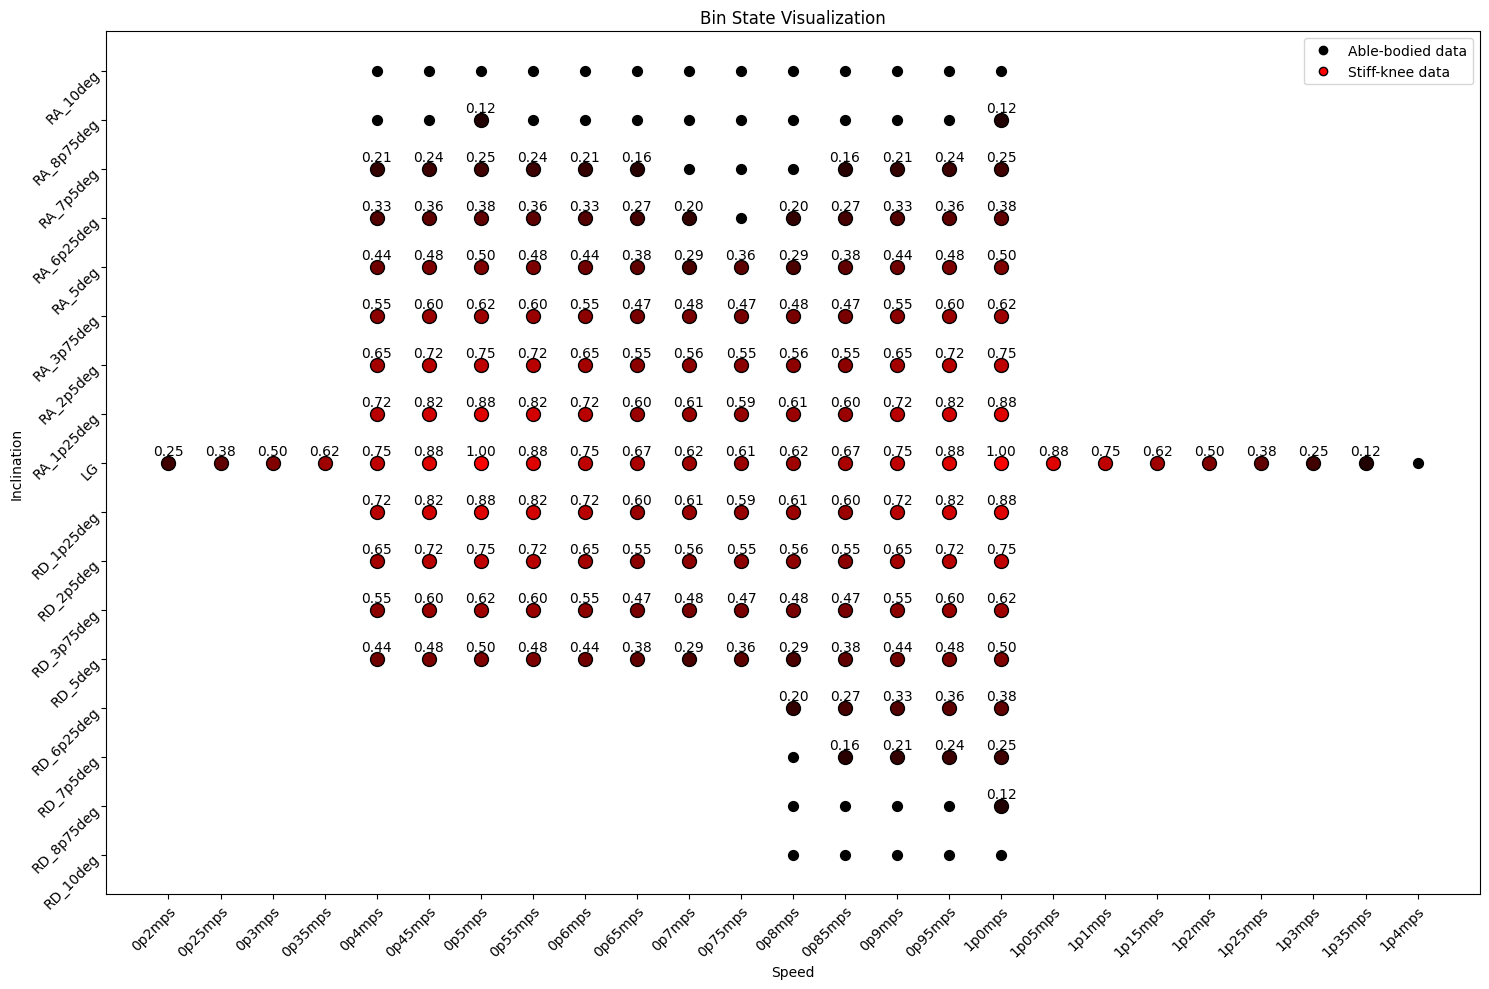

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# Prepare data for the 2D plot
bin_state_values = np.zeros((len(speeds_all), len(inclinations_all)))

fig, ax = plt.subplots(figsize=(15, 10))

# Iterate through the bin_state dictionary and extract values for the first gait cycle
for i, inclination in enumerate(inclinations_all):
    for j, speed in enumerate(speeds_all):

        bin_state_value = bin_state[inclination][speed][0]
        if bin_state_value is None:
            continue
        if bin_state_value == 0:
            ax.scatter(j, i, color='black', marker='o', s=50)  # Mark False values with gray circles
        elif bin_state_value <= 1:
            ax.scatter(j, i, color=[bin_state_value, 0, 0], marker='o', edgecolor='black', s=100)  # Mark True values with white circles
            ax.text(j, i+0.1, f'{bin_state_value:.2f}', ha='center', va='bottom')

            
# Set labels and title
ax.set_yticks(np.arange(len(inclinations_all)))
ax.set_xticks(np.arange(len(speeds_all)))
ax.set_yticklabels(inclinations_all)
ax.set_xticklabels(speeds_all)
plt.setp(ax.get_yticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

ax.set_title('Bin State Visualization')
ax.set_ylabel('Inclination')
ax.set_xlabel('Speed')

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Able-bodied data', markerfacecolor='black', markeredgecolor='black',),
    plt.Line2D([0], [0], marker='o', color='w', label='Stiff-knee data', markerfacecolor='red', markeredgecolor='black',)
]
ax.legend(handles=legend_elements, loc='upper right')

fig.tight_layout()
plt.show()

In [87]:
import plotly.graph_objects as go

# Prepare data for the 3D plot
x = []
y = []
z = []

ch_idx = 12

for i, inclination in enumerate(inclinations_all):
    for j, speed in enumerate(speeds_all):
        if bin_state[inclination][speed][0] is not None:
            x.append(i)
            y.append(j)
            z.append(np.mean(avg_input_gait_cycles[inclination][speed][0][ch_idx]))  # Example: using the mean of the 14th feature of the first gait cycle

# Create the 3D plot using Plotly
fig = go.Figure(data=[go.Mesh3d(
    x=x,    y=y,    z=z,
    opacity=0.25,    color='black',    showscale=True
), go.Scatter3d(
    x=x,    y=y,    z=z,
    mode='markers',
    marker=dict(
        size=5,        color='black',        opacity=0.5
    )
)])

# Customize the layout
fig.update_layout(
    title=f'Bin State Visualization (3D) - {sensing_ch[ch_idx]}',
    scene=dict(
        xaxis_title='Inclination',        yaxis_title='Speed',        zaxis_title=f'Mean value of {sensing_ch[ch_idx]}',
        xaxis=dict(
            tickvals=list(range(len(inclinations_all))),            ticktext=inclinations_all,            tickangle=-45
        ),
        yaxis=dict(
            tickvals=list(range(len(speeds_all))),            ticktext=speeds_all,            tickangle=-45
        ),
        zaxis=dict(
            tickvals=list(range(number_of_cycles)),            ticktext=[str(i) for i in range(number_of_cycles)]
        )
    ),
    width=1000,    height=1000
)

fig.show()

Interpolation of speed

In [83]:
from plotly.offline import iplot
import plotly.graph_objects as go

color_map = plt.get_cmap('tab20')
color_map.colors = list(color_map.colors)
color_map.colors.extend(color_map.colors[:5])
fig = go.Figure()

inclination = 'LG'
ch_idx = 13 # mtr_pos_L
for speed in speeds_all:
    if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
        continue
    if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
        continue

    color = f"rgba{tuple(int(c*255) for c in color_map.colors[speeds_all.index(speed)]) + (1,)}"
    z = speeds_all.index(speed) 

    gait_cycle = 0
    fig.add_trace(go.Scatter3d(
        x=np.arange(len(avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1])),
        y=avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1],  # Use index 1 for motor position
        z=[z] * len(avg_input_gait_cycles[inclination][speed][gait_cycle][ch_idx-1]),  # Create a z-coordinate for each point
        mode='lines',
        line=dict(color=color),   # <-- use line.color instead of marker
        name = speed + ' - gait cycle ' + str(gait_cycle + 1),
    ))
fig.update_layout(title=f'Average Gait Cycles - {inclination} - {sensing_ch[ch_idx-1]}')

fig.update_layout(
    scene=dict(
        xaxis_title='Time (s/100)',
        yaxis_title='Sensor signal value',
        zaxis_title='Gait cycle index',
    ),
    width=1250,
    height=750,
)
iplot(fig)

# Subject-level continuity (Before filling-up)

In [81]:
avg_input_gait_cycles_paretic = {inc: {spd: {gait_cycle: None for gait_cycle in range(number_of_cycles)} for spd in speeds_all} for inc in inclinations_all}

df_imu_paretic = pd.read_csv('/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/PT04_Changseob/sk_0p5/trial_1/Input/imu_data.csv')
df_mtr_paretic = pd.read_csv('/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/PT04_Changseob/sk_0p5/trial_1/Input/motor_positions.csv')

inclination = 'LG'
speed = '0p5mps'

imu_avg_gait_cycles_paretic, mtr_avg_gait_cycles_paretic = get_average_gait_cycle(df_imu_paretic, df_mtr_paretic, number_of_cycles=2)
avg_input_gait_cycles_paretic[inclination][speed][0] = np.vstack((imu_avg_gait_cycles_paretic[1:7], imu_avg_gait_cycles_paretic[13:19], mtr_avg_gait_cycles_paretic[2], mtr_avg_gait_cycles_paretic[4]))


In [82]:
def adjacent_task_personalization(current_inclination, current_speed, spread_distance):
    inclination_idx = inclinations_all.index(current_inclination)
    speed_idx = speeds_all.index(current_speed)

    for inclination in inclinations_all:
        for speed in speeds_all:
            if bin_state[inclination][speed][0] is not None:
                # Calculate the distance between the current task and the target task (in the 2D task space)
                task_distance = np.linalg.norm(np.array([inclinations_all.index(inclination), speeds_all.index(speed)]) - np.array([inclination_idx, speed_idx]))
                # Calculate the weight based on the distance (closer tasks have higher weights)
                task_weight = 1 - task_distance / (spread_distance + 1)

                if task_distance <= spread_distance:  
                    avg_input_gait_cycles[inclination][speed][0]\
                        = interpolate_two_cycles(avg_input_gait_cycles_paretic[current_inclination][current_speed][0], avg_input_gait_cycles[inclination][speed][0], weight= task_weight)
                    bin_state[inclination][speed][0] += (1 - bin_state[inclination][speed][0]) * task_weight

adjacent_task_personalization(inclination, speed, spread_distance=7)

In [7]:
scaling_map = mtr_avg_gait_cycles_sk[1]/(avg_input_gait_cycles['AB01_Jimin']['LG']['1p0mps'][12])  # Use the last subject as reference

print(mtr_avg_gait_cycles_sk[1][115:])
print(avg_input_gait_cycles['AB01_Jimin']['LG']['1p0mps'][12][115:])
print(scaling_map[115:])

print(scaling_map.shape)

# plt.plot(mtr_avg_gait_cycles_sk[1], label='SK04_Changseob', linestyle='--')
# plt.plot(avg_input_gait_cycles['AB01_Jimin']['LG']['1p0mps'][12], label='AB01_Jimin')
# plt.plot(avg_input_gait_cycles['AB02_Rajiv']['LG']['1p0mps'][12], label='AB02_Rajiv')
# plt.plot(avg_input_gait_cycles['AB03_Amy']['LG']['1p0mps'][12], label='AB03_Amy')
# plt.plot(avg_input_gait_cycles['AB04_Changseob']['LG']['1p0mps'][12], label='AB04_Changseob')
# plt.plot(avg_input_gait_cycles['AB05_Maria']['LG']['1p0mps'][12], label='AB05_Maria')
plt.plot(scaling_map)
plt.show()

ValueError: operands could not be broadcast together with shapes (120,) (118,) 

KeyError: 'AB01_Jimin'

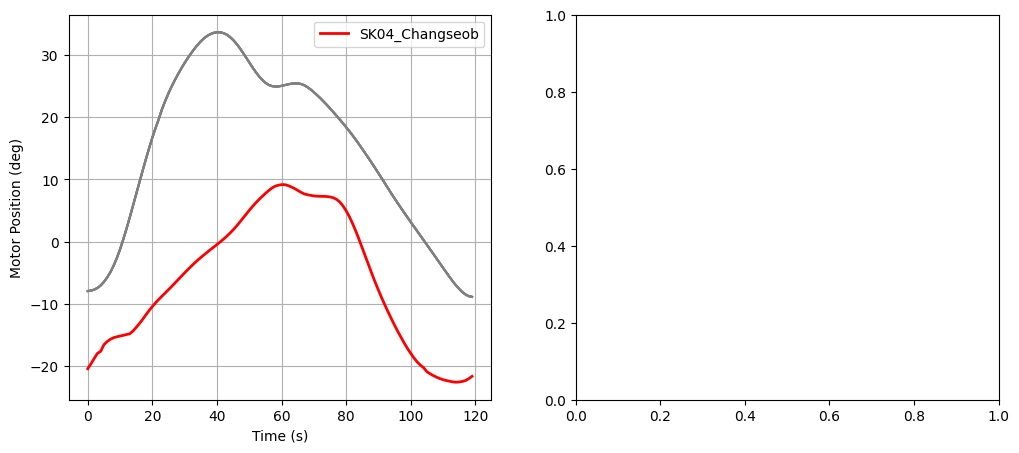

In [140]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))

for subject in subjects:
    axes[0].plot(avg_input_gait_cycles['LG']['1p0mps'][0][12], color='grey', alpha=0.5)
axes[0].plot(mtr_avg_gait_cycles_sk[2], color='red', label='SK04_Changseob', linewidth=2)  # Plot SK04_Changseob motor data
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Motor Position (deg)')
axes[0].legend()
axes[0].grid(True)

for subject in subjects:
    axes[1].plot(avg_input_gait_cycles[subject]['LG']['1p0mps'][13], color='grey', alpha=0.5)
axes[1].plot(mtr_avg_gait_cycles_sk[2], color='red', label='SK04_Changseob', linewidth=2)  # Plot SK04_Changseob motor data
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Motor Position (deg)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1,2, figsize=(12, 5))

for subject in subjects:
    axes[0].plot(avg_input_gait_cycles[subject]['LG']['0p8mps'][12], color='grey', alpha=0.5)
axes[0].plot(mtr_avg_gait_cycles_sk[1], color='red', label='SK04_Changseob', linewidth=2)  # Plot SK04_Changseob motor data
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Motor Position (deg)')
axes[0].legend()
axes[0].grid(True)

for subject in subjects:
    axes[1].plot(avg_input_gait_cycles[subject]['LG']['0p8mps'][13], color='grey', alpha=0.5)
axes[1].plot(mtr_avg_gait_cycles_sk[2], color='red', label='SK04_Changseob', linewidth=2)  # Plot SK04_Changseob motor data
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Motor Position (deg)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
subject_interpolated = {sub: None for sub in subjects}

def subject_interpolation(ab_data, sk_data):

    upsampled_ab_data = upsampling_2d(ab_data, 400)
    upsampled_sk_data = upsampling_2d(sk_data, 400)

    profile_mean = np.mean(np.array([upsampled_sk_data, upsampled_ab_data]), axis=0)
    period_mean = int(np.mean(np.array([len(ab_data[0]), len(sk_data[0])])))

    subject_interpolated[subject] = upsampling_2d(profile_mean, period_mean)

# Interpolate for unseen speeds and seen inclinations
for subject in subjects:

    ab_data = avg_input_gait_cycles[subject]['LG']['0p7mps']
    sk_data = avg_input_gait_cycles_sk

    subject_interpolation(ab_data, sk_data)

for subject in subjects:
    print(f"Subject: {subject}, Interpolated Data Shape: {subject_interpolated[subject].shape}")

Subject: AB01_Jimin, Interpolated Data Shape: (16, 131)
Subject: AB02_Rajiv, Interpolated Data Shape: (16, 128)
Subject: AB03_Amy, Interpolated Data Shape: (16, 134)
Subject: AB04_Changseob, Interpolated Data Shape: (16, 132)
Subject: AB05_Maria, Interpolated Data Shape: (16, 128)
Subject: AB07_Leo, Interpolated Data Shape: (16, 134)
Subject: AB08_Adrian, Interpolated Data Shape: (16, 146)
Subject: AB11_Ryan, Interpolated Data Shape: (16, 127)
Subject: AB12_Ray, Interpolated Data Shape: (16, 133)
Subject: AB13_Hridayam, Interpolated Data Shape: (16, 125)


(13, 10)
[18.15571565 15.90905042 12.98526418 11.64815179 10.23006034  8.93789364
  7.38224773  5.96197868  4.74223901  4.17166942  4.64682136  4.98281043
  5.62205837]


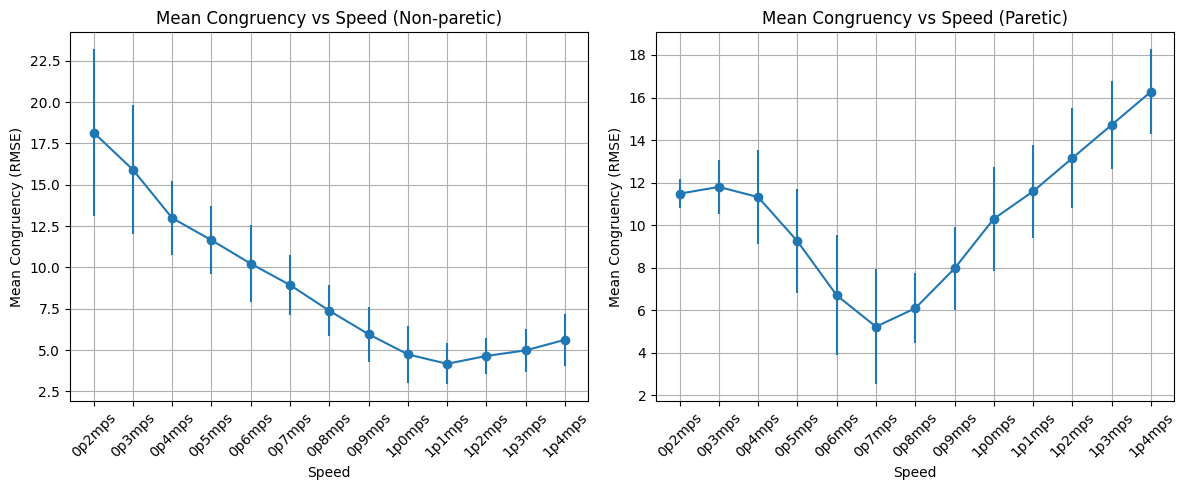

In [ ]:
congruency_speed_L = np.zeros((len(speeds_all), len(subjects)))
congruency_speed_R = np.zeros((len(speeds_all), len(subjects)))

for speed in speeds_all:
    for inclination in inclinations_all:
        if inclination != 'LG':  # Only check for LG
            continue
        for subject in subjects:
            congruency_speed_L[speeds_all.index(speed), subjects.index(subject)] = get_congruency_rmse(avg_input_gait_cycles[subject][inclination][speed][12], mtr_avg_gait_cycles_sk[1])
            congruency_speed_R[speeds_all.index(speed), subjects.index(subject)] = get_congruency_rmse(avg_input_gait_cycles[subject][inclination][speed][13], mtr_avg_gait_cycles_sk[2])

print(congruency_speed_L.shape)
print(np.mean(congruency_speed_L, axis=1))

# Plot the mean congruency for each speed
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].errorbar(speeds_all, np.mean(congruency_speed_L, axis=1), yerr=np.std(congruency_speed_L, axis=1), marker='o')
axes[0].set_xlabel('Speed')
axes[0].set_ylabel('Mean Congruency (RMSE)')
axes[0].set_title('Mean Congruency vs Speed (Non-paretic)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)

axes[1].errorbar(speeds_all, np.mean(congruency_speed_R, axis=1), yerr=np.std(congruency_speed_R, axis=1), marker='o')
axes[1].set_xlabel('Speed')
axes[1].set_ylabel('Mean Congruency (RMSE)')
axes[1].set_title('Mean Congruency vs Speed (Paretic)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)

plt.tight_layout()
plt.show()


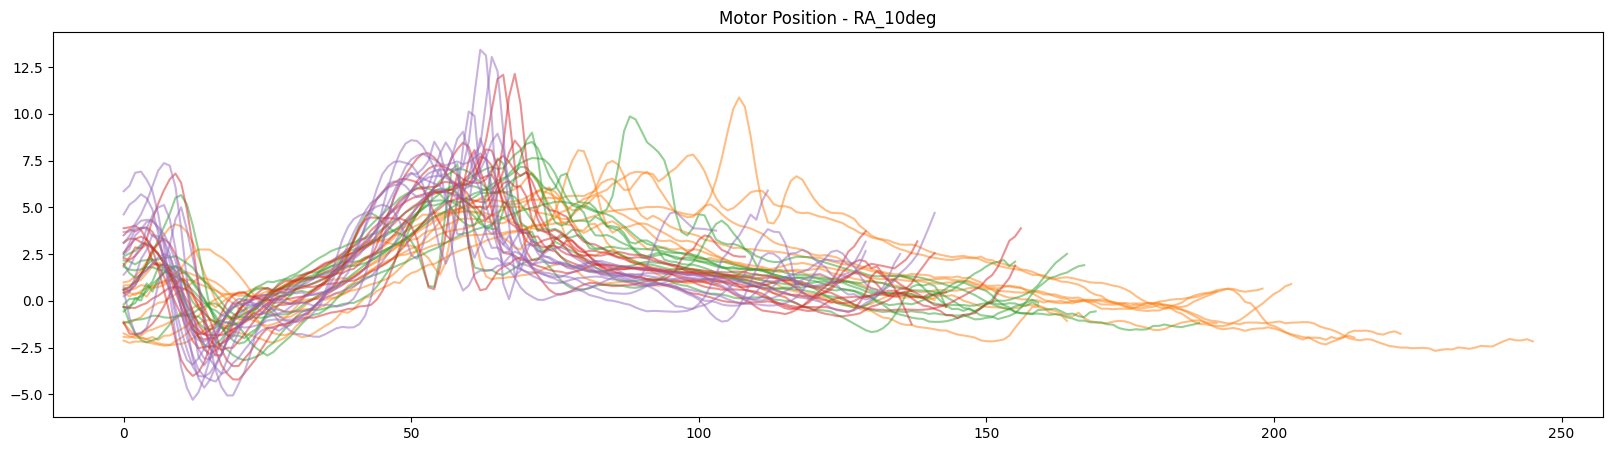

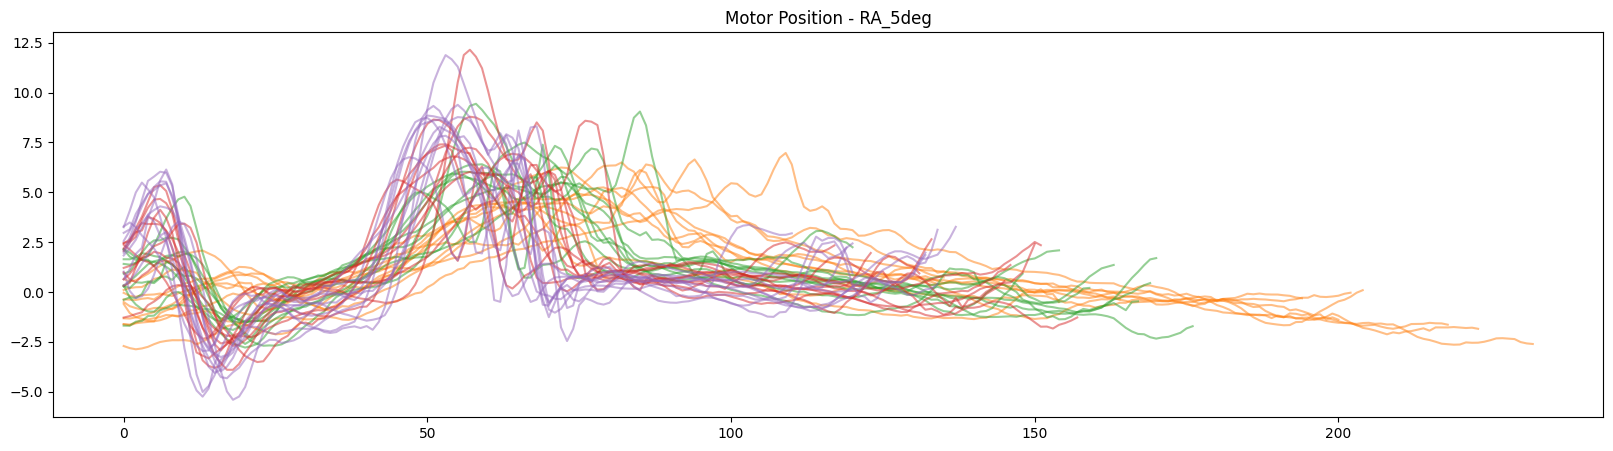

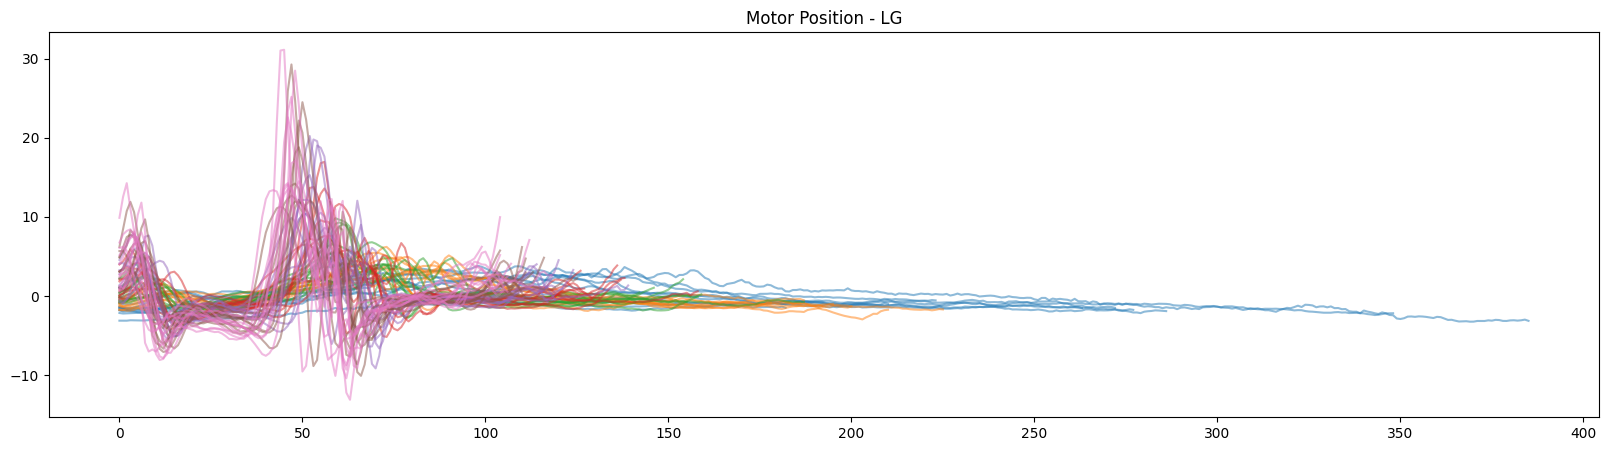

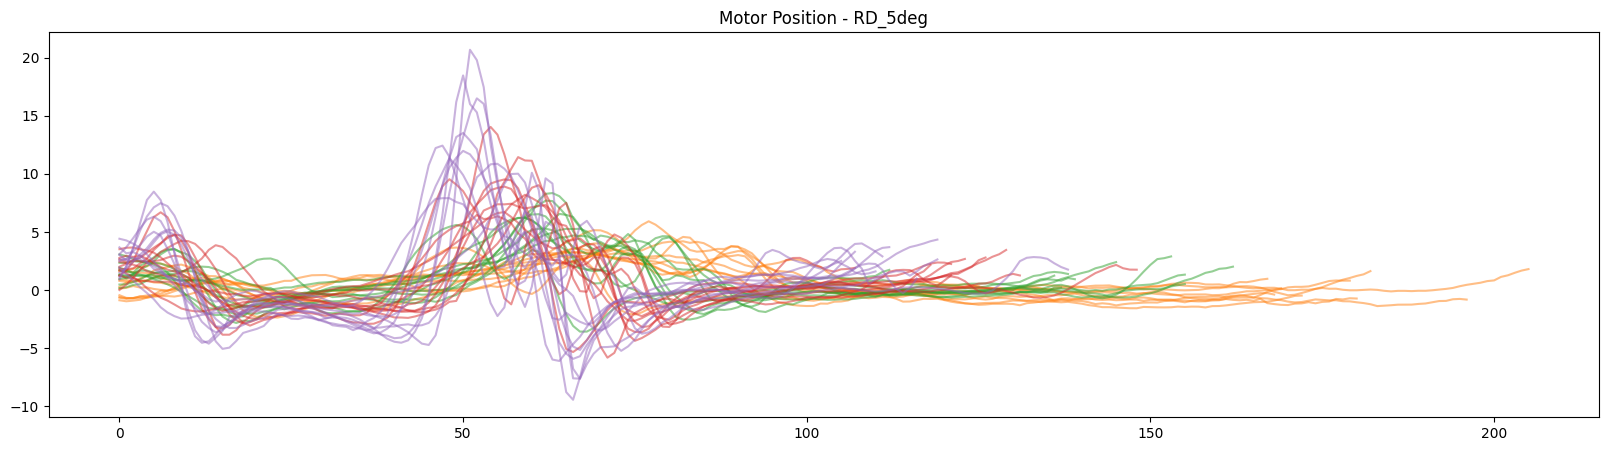

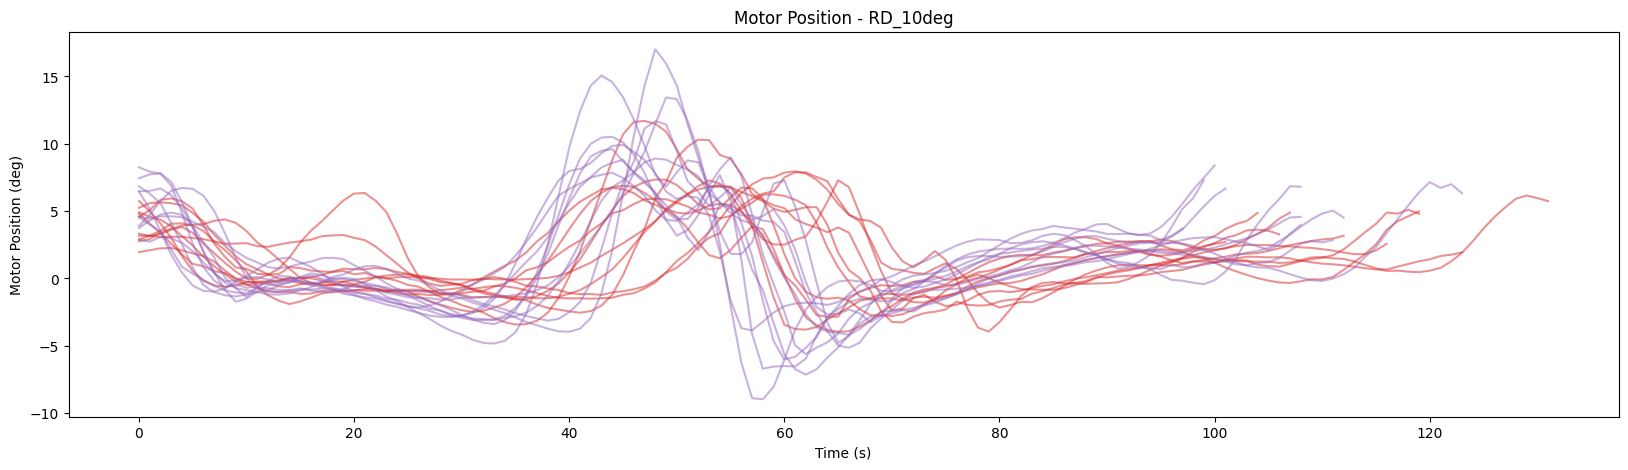

In [ ]:
color_map = plt.get_cmap('tab10')

for inclination in inclinations:
    plt.figure(figsize=(20, 5))
    plt.title(f'Motor Position - {inclination}')
    # plt.xlim(0, 450)
    # plt.ylim(-20, 60)
    for speed in speeds:
        if inclination != 'LG' and speed not in ['0p4mps', '0p6mps', '0p8mps', '1p0mps']:
                continue
        if inclination == 'RD_10deg' and speed in ['0p4mps', '0p6mps']:
                continue
        for subject in subjects:
            plt.plot(imu_avg_gait_cycles[subject][inclination][speed][9], label=subject, color=color_map.colors[speeds.index(speed)], alpha=0.5)

plt.xlabel('Time (s)')
plt.ylabel('Motor Position (deg)')
# plt.legend()
plt.show()

Number of gait cycles: 6
[ 442  786 1125 1572 1897 2271 2628]
Number of gait cycles: 12
[  91  319  526  739  956 1169 1382 1598 1814 2022 2238 2470 2684]
Number of gait cycles: 16
[ 117  293  452  624  791  953 1116 1284 1451 1614 1777 1943 2104 2277
 2441 2592 2766]
Number of gait cycles: 21
[  37  170  300  437  563  693  822  951 1081 1210 1347 1473 1610 1749
 1874 2013 2150 2286 2418 2552 2680 2814]
Number of gait cycles: 22
[ 138  266  388  517  642  766  889 1018 1143 1266 1395 1517 1642 1764
 1886 2012 2134 2257 2380 2502 2625 2747 2876]
Number of gait cycles: 24
[  92  210  319  433  547  662  778  891 1004 1118 1226 1344 1457 1575
 1690 1809 1925 2039 2148 2269 2384 2498 2613 2730 2839]
Number of gait cycles: 26
[  71  181  291  399  507  617  730  840  948 1057 1163 1269 1377 1485
 1595 1701 1812 1918 2022 2130 2234 2345 2452 2559 2668 2774 2884]
Number of gait cycles: 131
[  183   312   427   556   684   806   934  1058  1182  1312  1440  1567
  1689  1819  1947  2070  2193

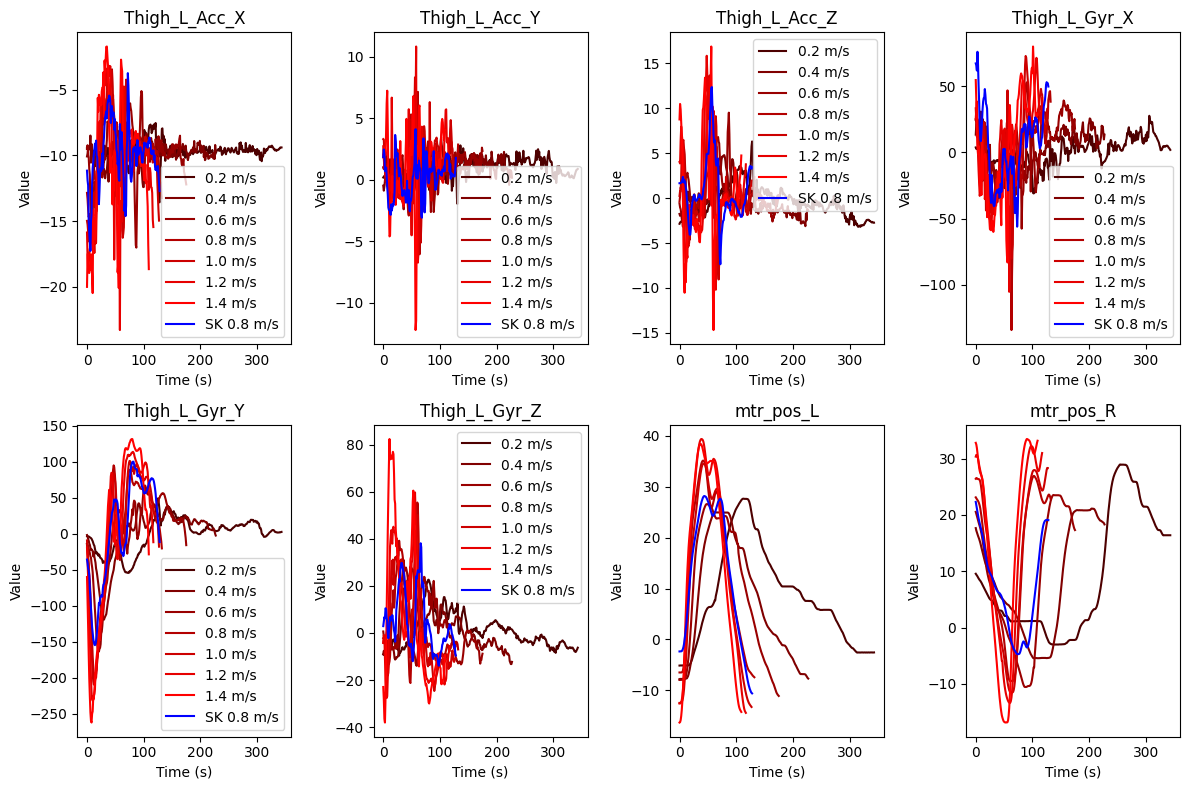

In [47]:
def plot_imu_and_motor_data(df_imu, df_mtr, axes, color, label):
    # Extract features
    peak_indices, _ = find_peaks(-df_mtr['mtr_pos_L'], height= None, distance=80, prominence=10)
    print(f"Number of gait cycles: {len(peak_indices) - 1}")

    # Use only the data between the first and last peaks
    print(peak_indices)
    x = np.arange(peak_indices[0], peak_indices[1])
    x_offset = x - peak_indices[0]

    # Plot IMU data on the subplots
    axes[0].plot(x_offset, df_imu['Thigh_L_Acc_X'][x], label=label, color=color)
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Value')
    axes[0].set_title('Thigh_L_Acc_X')
    axes[0].legend()

    axes[1].plot(x_offset, df_imu['Thigh_L_Acc_Y'][x], label=label, color=color)
    axes[1].set_xlabel('Time (s)')
    axes[1].set_ylabel('Value')
    axes[1].set_title('Thigh_L_Acc_Y')
    axes[1].legend()

    axes[2].plot(x_offset, df_imu['Thigh_L_Acc_Z'][x], label=label, color=color)
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Value')
    axes[2].set_title('Thigh_L_Acc_Z')
    axes[2].legend()

    axes[3].plot(x_offset, df_imu['Thigh_L_Gyr_X'][x], label=label, color=color)
    axes[3].set_xlabel('Time (s)')
    axes[3].set_ylabel('Value')
    axes[3].set_title('Thigh_L_Gyr_X')
    axes[3].legend()

    axes[4].plot(x_offset, df_imu['Thigh_L_Gyr_Y'][x], label=label, color=color)
    axes[4].set_xlabel('Time (s)')
    axes[4].set_ylabel('Value')
    axes[4].set_title('Thigh_L_Gyr_Y')
    axes[4].legend()

    axes[5].plot(x_offset, df_imu['Thigh_L_Gyr_Z'][x], label=label, color=color)
    axes[5].set_xlabel('Time (s)')
    axes[5].set_ylabel('Value')
    axes[5].set_title('Thigh_L_Gyr_Z')
    axes[5].legend()

    axes[6].plot(x_offset, df_mtr['mtr_pos_L'][x], label=label, color=color)
    axes[6].set_xlabel('Time (s)')
    axes[6].set_ylabel('Value')
    axes[6].set_title('mtr_pos_L')
    # axes[6].legend()

    axes[7].plot(x_offset, -df_mtr['mtr_pos_R'][x], label=label, color=color)
    axes[7].set_xlabel('Time (s)')
    axes[7].set_ylabel('Value')
    axes[7].set_title('mtr_pos_R')
    # axes[7].legend()

    plt.tight_layout()


# Create a single figure and axes
fig, axes = plt.subplots(2, 4, figsize=(12, 8))
axes = axes.flatten()

subject = 'AB04_Changseob'

df_imu_02 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p2mps/trial_1/Input/imu_data.csv')
df_mtr_02 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p2mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_02, df_mtr_02, axes, [0.3, 0, 0], '0.2 m/s')

df_imu_04 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p4mps/trial_1/Input/imu_data.csv')
df_mtr_04 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p4mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_04, df_mtr_04, axes, [0.5, 0, 0], '0.4 m/s')

df_imu_06 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p6mps/trial_1/Input/imu_data.csv')
df_mtr_06 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p6mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_06, df_mtr_06, axes, [0.6, 0, 0], '0.6 m/s')

df_imu_08 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p8mps/trial_1/Input/imu_data.csv')
df_mtr_08 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/0p8mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_08, df_mtr_08, axes, [0.7, 0, 0], '0.8 m/s')

df_imu_10 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p0mps/trial_1/Input/imu_data.csv')
df_mtr_10 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p0mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_10, df_mtr_10, axes, [0.8, 0, 0], '1.0 m/s')

df_imu_12 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p2mps/trial_1/Input/imu_data.csv')
df_mtr_12 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p2mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_12, df_mtr_12, axes, [0.9, 0, 0], '1.2 m/s')

df_imu_14 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p4mps/trial_1/Input/imu_data.csv')
df_mtr_14 = pd.read_csv(f'/home/metamobility5/Changseob/dataset-MeMo/Synced_LGRARD/{subject}/LG/1p4mps/trial_1/Input/motor_positions.csv')
plot_imu_and_motor_data(df_imu_14, df_mtr_14, axes, [1.0, 0, 0], '1.4 m/s')

df_imu = pd.read_csv('/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/SK04_Changseob/SK04_Changseob_LG_L1p0_R0p6_imu_data.csv')
df_mtr = pd.read_csv('/home/metamobility5/Changseob/proj-online_adaptation_GPE/subject_data/SK04_Changseob/SK04_Changseob_LG_L1p0_R0p6_motor_positions.csv')
plot_imu_and_motor_data(df_imu, df_mtr, axes, [0, 0, 1.0], 'SK 0.8 m/s')

plt.show()

